# View QPT results

Loads saved quantum-process-tomography (QPT) result files from `Results/QPT/` and
cross-checks the saved Choi matrix two ways:

In [1]:
import json, glob, os, logging
import numpy as np
import matplotlib.pyplot as plt

from qiskit.quantum_info import Choi, Operator, process_fidelity
from qiskit.circuit.library import XGate, SXGate

from qiskit_experiments.library.tomography.basis import PauliPreparationBasis, PauliMeasurementBasis
from qiskit_experiments.library.tomography.fitters import linear_inversion, tomography_fitter_data

# the target gate depends on which file is loaded ('qpt_sx_*' -> SX, everything else -> X);
# picked per file in the "select file + implementation" cell below
IDEAL_CHOI_BY_GATE = {'x': Choi(Operator(XGate())), 'sx': Choi(Operator(SXGate()))}

# experimental Choi matrices are noisy and routinely fail the strict CP/TP checks that
# qiskit's process_fidelity() logs a warning for on every call (incl. every bootstrap
# resample) — silence that and report it ourselves, once, where relevant instead.
logging.getLogger('qiskit.quantum_info.operators.measures').setLevel(logging.ERROR)


def note_if_not_cp(C, label):
    eigs = np.linalg.eigvalsh(Choi(C).data)
    if eigs.min() < -1e-8:
        print(f'Note: {label} channel is not CP — Choi-matrix has negative eigenvalues (min={eigs.min():.4f}); '
              'expected for noisy experimental data.')


In [2]:
# ── discover QPT result files ───────────────────────────────────────────────────────
RESULTS_DIR = 'Results/QPT'
PATTERNS    = ['qpt_sx*.json', 'qpt_x*.json']

files = []
for pattern in PATTERNS:
    files += glob.glob(os.path.join(RESULTS_DIR, pattern))
files = sorted(set(files), key=os.path.getmtime)

print(f'{len(files)} file(s) found:\n')
for i, f in enumerate(files):
    print(f'[{i}]  {f}')


5 file(s) found:

[0]  Results/QPT/qpt_sx_QB53_emerald_20260611_141807.json
[1]  Results/QPT/qpt_sx_QB53_emerald_20260612_144455.json
[2]  Results/QPT/qpt_x_QB7_garnet_20260615_134814.json
[3]  Results/QPT/qpt_sx_QB7_garnet_20260718_184944.json
[4]  Results/QPT/qpt_sx_QB47_emerald_20260718_215345.json


In [3]:
# each file compares two gate implementations ('dakis' vs. 'native') side by side,
# with fields nested under dakis_calibration / native_gate / choi_matrix / results_*

def fmt(x, spec='.5f'):
    """Format a possibly-missing ('N/A') or non-numeric field without blowing up."""
    try:
        return format(float(x), spec)
    except (TypeError, ValueError):
        return str(x)


def fmt_pm(value, std, spec='.6f'):
    """Format 'value' with a '± std' suffix when std is available, else bare."""
    if std is None:
        return fmt(value, spec)
    return f'{fmt(value, spec)} ± {fmt(std, spec)}'


def normalize_qpt_file(path):
    with open(path) as fp:
        d = json.load(fp)

    common = dict(
        qubit=d.get('qubit', 'N/A'),
        machine=d.get('machine', 'N/A'),
        calibration_set_id=d.get('calibration_set_id', 'N/A'),
        timestamp=d.get('timestamp', 'N/A'),
        n_shots=d.get('n_shots'),
    )

    pf = d.get('process_fidelity', {}) or {}
    cm = d['choi_matrix']
    dc = d.get('dakis_calibration', {}) or {}
    ng = d.get('native_gate', {}) or {}

    impls = {}
    impls['dakis'] = dict(
        Texp_ns=dc.get('Texp_ns', 'N/A'),
        amp=dc.get('amp_pi', dc.get('amp_sx', dc.get('amp_x', 'N/A'))),
        process_fidelity=pf.get('dakis', 'N/A'),
        choi_real=cm.get('dakis_real'),
        choi_imag=cm.get('dakis_imag'),
        qpt_results=d.get('results_dakis', []),
    )
    impls['native'] = dict(
        Texp_ns=ng['duration'] * 1e9 if 'duration' in ng else 'N/A',
        amp=ng.get('amplitude_i', 'N/A'),
        process_fidelity=pf.get('native', 'N/A'),
        choi_real=cm.get('native_real'),
        choi_imag=cm.get('native_imag'),
        qpt_results=d.get('results_native', []),
    )
    ir, ii = cm.get('ideal_real'), cm.get('ideal_imag')
    common['choi_ideal_saved'] = (np.array(ir) + 1j * np.array(ii)) if ir is not None else None

    return dict(common, implementations=impls, path=path)


infos = [normalize_qpt_file(f) for f in files]

for i, info in enumerate(infos):
    print(f"[{i}]  {os.path.basename(info['path'])}")
    print(f"      qubit={info['qubit']},  machine={info['machine']},  timestamp={str(info['timestamp'])[:19]},  "
          f"n_shots={info['n_shots'] if info['n_shots'] is not None else 'N/A'}")
    for name, impl in info['implementations'].items():
        print(f"      · {name:<6s} Texp_ns={fmt(impl['Texp_ns'], '.1f')},  amp={fmt(impl['amp'])},  "
              f"F_saved={fmt(impl['process_fidelity'], '.6f')}")
    print()


[0]  qpt_sx_QB53_emerald_20260611_141807.json
      qubit=QB53,  machine=emerald,  timestamp=2026-06-11T14:18:07,  n_shots=1000
      · dakis  Texp_ns=40.0,  amp=0.17702,  F_saved=1.007598
      · native Texp_ns=24.0,  amp=0.29955,  F_saved=1.004640

[1]  qpt_sx_QB53_emerald_20260612_144455.json
      qubit=QB53,  machine=emerald,  timestamp=2026-06-12T14:44:55,  n_shots=1000
      · dakis  Texp_ns=40.0,  amp=0.17702,  F_saved=1.046680
      · native Texp_ns=24.0,  amp=0.30014,  F_saved=1.007973

[2]  qpt_x_QB7_garnet_20260615_134814.json
      qubit=QB7,  machine=garnet,  timestamp=2026-06-15T13:48:14,  n_shots=2000
      · dakis  Texp_ns=40.0,  amp=0.24925,  F_saved=0.998900
      · native Texp_ns=16.0,  amp=0.23916,  F_saved=1.001873

[3]  qpt_sx_QB7_garnet_20260718_184944.json
      qubit=QB7,  machine=garnet,  timestamp=2026-07-18T18:49:44,  n_shots=1000
      · dakis  Texp_ns=40.0,  amp=0.10090,  F_saved=1.010419
      · native Texp_ns=16.0,  amp=0.23463,  F_saved=1.010526

[4]  

In [4]:
# ── select file + implementation  
idx = 0                             # -1 = most recent file
impl_name = 'dakis'                 # 'dakis' or 'native'



info = infos[idx]
impl = info['implementations'][impl_name]
n_shots = info['n_shots']

# 'qpt_sx_*' files are QPT of an SX (sqrt-X) gate; everything else is a full X gate.
# Comparing an SX-gate Choi matrix against an ideal X target (or vice versa) silently
# gives F ≈ 0.5 — that's two unrelated single-qubit unitaries, not a fitter bug.
gate_tokens = os.path.basename(info['path']).lower().replace('.json', '').split('_')
gate = 'sx' if 'sx' in gate_tokens else 'x'
ideal_choi = IDEAL_CHOI_BY_GATE[gate]

print(f"File:               {os.path.basename(info['path'])}")
print(f"implementation:     {impl_name}  (available: {list(info['implementations'])})")
print(f"target gate:        {gate.upper()}  (inferred from filename)")
print(f"qubit:              {info['qubit']}")
print(f"machine:            {info['machine']}")
print(f"calibration_set_id: {info['calibration_set_id']}")
print(f"timestamp:          {str(info['timestamp'])[:19]}")
print(f"n_shots:            {n_shots if n_shots is not None else 'N/A'}")
print(f"Texp_ns:            {fmt(impl['Texp_ns'], '.1f')}")
print(f"amp:                {fmt(impl['amp'])}")
print(f"process_fidelity:   {fmt(impl['process_fidelity'], '.6f')}  (saved)")

C_saved = np.array(impl['choi_real']) + 1j * np.array(impl['choi_imag'])
qpt_records = [r for r in impl['qpt_results'] if r['metadata'].get('kind') == 'qpt']
rem_records = [r for r in impl['qpt_results'] if r['metadata'].get('kind') == 'rem']


File:               qpt_sx_QB53_emerald_20260611_141807.json
implementation:     dakis  (available: ['dakis', 'native'])
target gate:        SX  (inferred from filename)
qubit:              QB53
machine:            emerald
calibration_set_id: 89d0e77c-b042-433d-8a6e-574563603ea1
timestamp:          2026-06-11T14:18:07
n_shots:            1000
Texp_ns:            40.0
amp:                0.17702
process_fidelity:   1.007598  (saved)


In [5]:
# ── 1) Reproduce: re-run our own reconstruct_choi/REM-correction on the saved probs ───
I2 = np.eye(2, dtype=complex)
sx = np.array([[0,  1 ], [1,  0 ]], dtype=complex)
sy = np.array([[0, -1j], [1j, 0 ]], dtype=complex)
sz = np.array([[1,  0 ], [0, -1 ]], dtype=complex)


def _rem_correct(prob, p10, p01):
    denom = 1 - p01 - p10
    return np.clip((prob - p10) / denom, 0, 1) if abs(denom) > 1e-6 else prob


def reconstruct_choi_local(qpt_records, rem_records, key='prob_raw'):
    rem0 = next(r for r in rem_records if r['metadata'].get('true_state') == 0)
    rem1 = next(r for r in rem_records if r['metadata'].get('true_state') == 1)
    p10 = rem0[key]; p01 = 1 - rem1[key]

    p = np.full((4, 3), np.nan)
    for r in qpt_records:
        m = r['metadata']
        p[m['prep_index'], m['meas_index']] = _rem_correct(r[key], p10, p01)

    sigma = []
    for j in range(4):
        x = 1 - 2*p[j,1]; y = 1 - 2*p[j,2]; z = 1 - 2*p[j,0]
        sigma.append((I2 + x*sx + y*sy + z*sz) / 2)

    A = 2*sigma[2] - sigma[0] - sigma[1]
    B = -1j * (2*sigma[3] - sigma[0] - sigma[1])
    C = np.block([[sigma[0], (A-B)/2], [(A+B)/2, sigma[1]]])
    return C, p


def bootstrap_fidelity_std(qpt_records, rem_records, ideal_choi, n_shots, n_boot=400, seed=0):
    """Shot-noise error bar on process_fidelity via parametric (binomial) bootstrap.

    Each measured prob_raw is treated as a Binomial(n_shots, p_hat)/n_shots draw; we
    resample it n_boot times, re-run reconstruct_choi_local each time, and take the std
    of the resulting fidelities.
    """
    if not n_shots:
        return None
    rng = np.random.default_rng(seed)
    Fs = np.empty(n_boot)
    for b in range(n_boot):
        qpt_b = [{**r, 'prob_raw': rng.binomial(n_shots, np.clip(r['prob_raw'], 0, 1)) / n_shots}
                 for r in qpt_records]
        rem_b = [{**r, 'prob_raw': rng.binomial(n_shots, np.clip(r['prob_raw'], 0, 1)) / n_shots}
                 for r in rem_records]
        C_b, _ = reconstruct_choi_local(qpt_b, rem_b, key='prob_raw')
        # require_cp/tp=False: bootstrap resamples are individually noisy and routinely
        # non-CP by construction — that's not informative per-resample, only the spread matters.
        Fs[b] = process_fidelity(Choi(C_b), ideal_choi, require_cp=False, require_tp=False).real
    return float(Fs.std(ddof=1))


C_local, p_local = reconstruct_choi_local(qpt_records, rem_records, key='prob_raw')
note_if_not_cp(C_local, 'reconstructed (local)')
F_local = process_fidelity(Choi(C_local), ideal_choi).real
F_local_std = bootstrap_fidelity_std(qpt_records, rem_records, ideal_choi, n_shots)

print('Saved vs. recomputed (local) Choi — should match the file exactly:')
print(f'  |C_saved - C_local|_F = {np.linalg.norm(C_saved - C_local, "fro"):.2e}')
print(f'  F_saved   = {fmt(impl["process_fidelity"], ".6f")}')
print(f'  F_local   = {fmt_pm(F_local, F_local_std)}')


Note: reconstructed (local) channel is not CP — Choi-matrix has negative eigenvalues (min=-0.0863); expected for noisy experimental data.
Saved vs. recomputed (local) Choi — should match the file exactly:
  |C_saved - C_local|_F = 0.00e+00
  F_saved   = 1.007598
  F_local   = 1.007598 ± 0.009728


In [6]:
# ── 2) Cross-check: independent fit via qiskit-experiments linear_inversion ──────────
# Feed the SAME REM-corrected probabilities that reconstruct_choi_local uses, so this
# is a true apples-to-apples test of the *reconstruction math*, not a REM mismatch.

rem0 = next(r for r in rem_records if r["metadata"].get("true_state") == 0)
rem1 = next(r for r in rem_records if r["metadata"].get("true_state") == 1)
p10 = rem0["prob_raw"]; p01 = 1 - rem1["prob_raw"]

ASSUMED_N_SHOTS = 1_000_000

data_for_fit = [
    {"metadata": {"m_idx": (r["metadata"]["meas_index"],), "p_idx": (r["metadata"]["prep_index"],)},
     "counts": {"0": int(round((1 - _rem_correct(r["prob_raw"], p10, p01)) * ASSUMED_N_SHOTS)),
                "1": int(round(_rem_correct(r["prob_raw"], p10, p01) * ASSUMED_N_SHOTS))}}
    for r in qpt_records
]

outcome_data, shot_data, measurement_data, preparation_data = tomography_fitter_data(
    data_for_fit, clbits_key=None, cond_clbits_key=None
)

C_qe, _meta_qe = linear_inversion(
    outcome_data, shot_data, measurement_data, preparation_data,
    measurement_basis=PauliMeasurementBasis(), preparation_basis=PauliPreparationBasis(),
)
note_if_not_cp(C_qe, 'qiskit-experiments linear_inversion')
F_qe = process_fidelity(Choi(C_qe), ideal_choi).real

print("qiskit-experiments cross-check (REM-corrected probabilities, matching C_local exactly):")
print(f"  F_qiskit_experiments = {fmt_pm(F_qe, F_local_std)}")
print(f"  F_local              = {fmt_pm(F_local, F_local_std)}")
print(f"  F_saved              = {fmt(impl['process_fidelity'], '.6f')}")
print(f"  |C_qe - C_local|_F   = {np.linalg.norm(C_qe - C_local, 'fro'):.2e}")


Note: qiskit-experiments linear_inversion channel is not CP — Choi-matrix has negative eigenvalues (min=-0.0863); expected for noisy experimental data.
qiskit-experiments cross-check (REM-corrected probabilities, matching C_local exactly):
  F_qiskit_experiments = 1.007598 ± 0.009728
  F_local              = 1.007598 ± 0.009728
  F_saved              = 1.007598
  |C_qe - C_local|_F   = 1.43e-06


/tmp/ipykernel_47906/871179877.py:51: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_47906/871179877.py:51: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


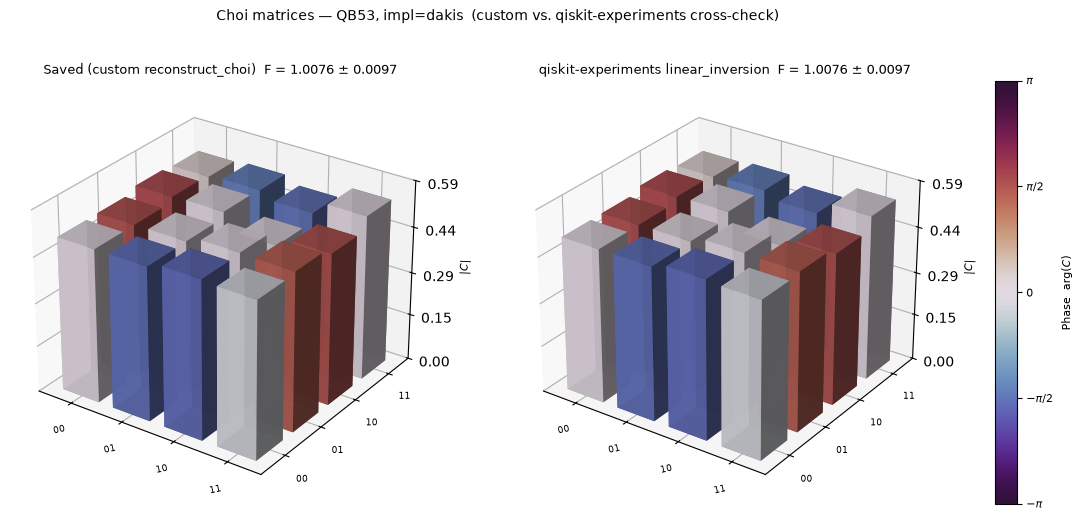

In [7]:
# ── Choi matrix visualisation: saved vs. qiskit-experiments cross-check ──────────────
from mpl_toolkits.mplot3d import Axes3D

BASIS_LABELS = ['00', '01', '10', '11']
CMAP = plt.cm.twilight_shifted

C_ideal = np.array(ideal_choi.data)
amp_max = float(max(np.abs(C_ideal).max(), np.abs(C_saved).max(), np.abs(C_qe).max())) * 1.10
amp_max = max(amp_max, 0.1)


def plot_choi_bars(C, ax, title, elev=28, azim=-55):
    n = C.shape[0]
    xi, yi = np.meshgrid(np.arange(n), np.arange(n), indexing='ij')
    xpos = xi.flatten().astype(float)
    ypos = yi.flatten().astype(float)
    dz    = np.abs(C).flatten()
    phase = np.angle(C).flatten()

    rgba = CMAP((phase + np.pi) / (2 * np.pi))
    rgba[:, 3] = np.where(dz < 0.01 * amp_max, 0.15, 0.88)

    ax.bar3d(xpos - 0.38, ypos - 0.38, np.zeros_like(xpos),
             0.72, 0.72, dz, color=rgba, shade=True, zsort='average')

    ax.set_zlim(0, amp_max)
    ax.set_zticks(np.round(np.linspace(0, amp_max, 5), 2))
    ax.set_xticks(np.arange(n)); ax.set_xticklabels(BASIS_LABELS, fontsize=6.5, rotation=12)
    ax.set_yticks(np.arange(n)); ax.set_yticklabels(BASIS_LABELS, fontsize=6.5)
    ax.set_zlabel(r'$|C|$', fontsize=8, labelpad=2)
    ax.set_title(title, fontsize=9, pad=6)
    ax.view_init(elev=elev, azim=azim)


fig = plt.figure(figsize=(13, 5.5))
ax1 = fig.add_subplot(121, projection='3d')
plot_choi_bars(C_saved, ax1, f"Saved (custom reconstruct_choi)  F = {fmt_pm(impl['process_fidelity'], F_local_std, '.4f')}")

ax2 = fig.add_subplot(122, projection='3d')
plot_choi_bars(C_qe, ax2, f"qiskit-experiments linear_inversion  F = {fmt_pm(F_qe, F_local_std, '.4f')}")

sm = plt.cm.ScalarMappable(cmap=CMAP, norm=plt.Normalize(-np.pi, np.pi))
sm.set_array([])
cbar = fig.colorbar(sm, ax=[ax1, ax2], fraction=0.022, pad=0.06,
                    ticks=[-np.pi, -np.pi/2, 0, np.pi/2, np.pi])
cbar.ax.set_yticklabels([r'$-\pi$', r'$-\pi/2$', '0', r'$\pi/2$', r'$\pi$'], fontsize=8)
cbar.set_label(r'Phase  $\arg(C)$', fontsize=8, labelpad=6)

plt.suptitle(f"Choi matrices — {info['qubit']}, impl={impl_name}  (custom vs. qiskit-experiments cross-check)",
             fontsize=10, y=1.01)
plt.tight_layout()
plt.show()


Note: dakis channel is not CP — Choi-matrix has negative eigenvalues (min=-0.0863); expected for noisy experimental data.
Note: native channel is not CP — Choi-matrix has negative eigenvalues (min=-0.0771); expected for noisy experimental data.


/tmp/ipykernel_47906/2445015063.py:32: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_47906/2445015063.py:32: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


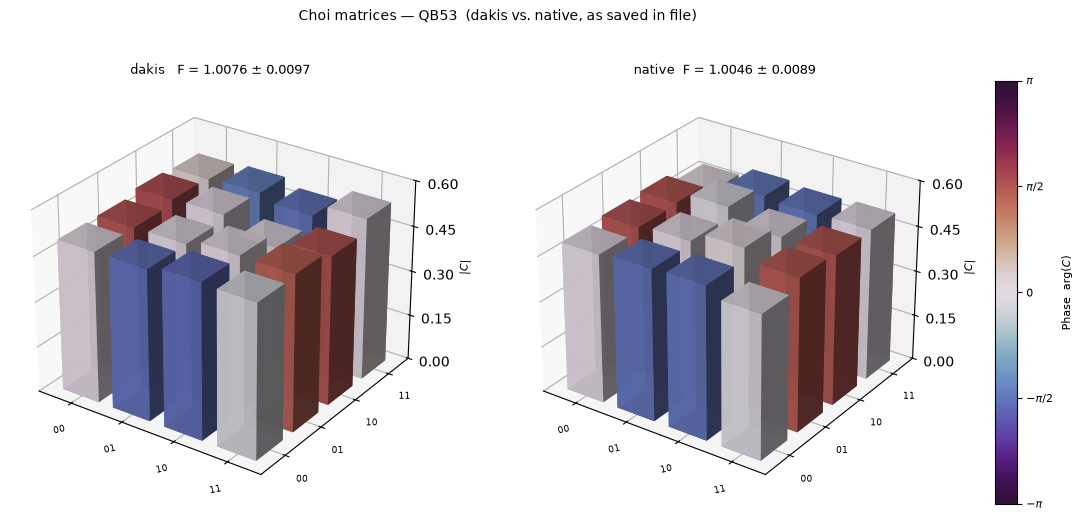

In [10]:
# ── SCQC vs. native side by side ─────────────────────────────────────────────────────
d_impl, n_impl = info['implementations']['dakis'], info['implementations']['native']
C_dakis = np.array(d_impl['choi_real']) + 1j * np.array(d_impl['choi_imag'])
C_native = np.array(n_impl['choi_real']) + 1j * np.array(n_impl['choi_imag'])
note_if_not_cp(C_dakis, 'dakis')
note_if_not_cp(C_native, 'native')

d_qpt = [r for r in d_impl['qpt_results'] if r['metadata'].get('kind') == 'qpt']
d_rem = [r for r in d_impl['qpt_results'] if r['metadata'].get('kind') == 'rem']
n_qpt = [r for r in n_impl['qpt_results'] if r['metadata'].get('kind') == 'qpt']
n_rem = [r for r in n_impl['qpt_results'] if r['metadata'].get('kind') == 'rem']
dakis_std = bootstrap_fidelity_std(d_qpt, d_rem, ideal_choi, n_shots)
native_std = bootstrap_fidelity_std(n_qpt, n_rem, ideal_choi, n_shots)

amp_max = float(max(np.abs(C_ideal).max(), np.abs(C_dakis).max(), np.abs(C_native).max())) * 1.10
amp_max = max(amp_max, 0.1)

fig = plt.figure(figsize=(13, 5.5))
ax1 = fig.add_subplot(121, projection='3d')
plot_choi_bars(C_dakis, ax1, f"dakis   F = {fmt_pm(d_impl['process_fidelity'], dakis_std, '.4f')}")
ax2 = fig.add_subplot(122, projection='3d')
plot_choi_bars(C_native, ax2, f"native  F = {fmt_pm(n_impl['process_fidelity'], native_std, '.4f')}")

sm = plt.cm.ScalarMappable(cmap=CMAP, norm=plt.Normalize(-np.pi, np.pi))
sm.set_array([])
cbar = fig.colorbar(sm, ax=[ax1, ax2], fraction=0.022, pad=0.06,
                    ticks=[-np.pi, -np.pi/2, 0, np.pi/2, np.pi])
cbar.ax.set_yticklabels([r'$-\pi$', r'$-\pi/2$', '0', r'$\pi/2$', r'$\pi$'], fontsize=8)
cbar.set_label(r'Phase  $\arg(C)$', fontsize=8, labelpad=6)

plt.suptitle(f"Choi matrices — {info['qubit']}  (dakis vs. native, as saved in file)", fontsize=10, y=1.01)
plt.tight_layout()
plt.show()
